In [2]:
import pandas as pd 
import numpy as np 
import fastf1
import os
os.makedirs("cache",exist_ok=True)
fastf1.Cache.enable_cache("cache")

In [3]:
df=pd.read_csv("dataset/f1_tire_strategy_dataset.csv")
df.head()

/var/folders/z9/mfjky7990sl75cj7j56dg6gh0000gn/T/ipykernel_73943/1421234542.py:1: DtypeWarning: Columns (4,14,15,16,17,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("dataset/f1_tire_strategy_dataset.csv")


,Driver,LapNumber,LapTime,Stint,PitInTime,PitOutTime,Year,Round,TireAge,LapTimeSeconds,...,lap,milliseconds,RaceProgress,Compound_HARD,Compound_INTERMEDIATE,Compound_MEDIUM,Compound_SOFT,Compound_UNKNOWN,Compound_WET,TrackName
0,GAS,1.0,0 days 00:01:19.106000,1.0,NaN,NaN,2020,1,1.0,79.106,...,NaN,NaN,0.011494,False,False,True,False,False,False,Red Bull Ring
1,GAS,1.0,0 days 00:01:19.106000,1.0,NaN,NaN,2020,1,1.0,79.106,...,NaN,NaN,0.011494,False,False,True,False,False,False,Red Bull Ring
2,GAS,1.0,0 days 00:01:19.106000,1.0,NaN,NaN,2020,1,1.0,79.106,...,NaN,NaN,0.011494,False,False,True,False,False,False,Red Bull Ring
3,GAS,1.0,0 days 00:01:19.106000,1.0,NaN,NaN,2020,1,1.0,79.106,...,NaN,NaN,0.011494,False,False,True,False,False,False,Red Bull Ring
4,GAS,1.0,0 days 00:01:19.106000,1.0,NaN,NaN,2020,1,1.0,79.106,...,NaN,NaN,0.011494,False,False,True,False,False,False,Red Bull Ring


In [3]:
df.isna().sum()

Driver                         0
LapNumber                      0
LapTime                        0
Stint                        446
PitInTime                1580540
PitOutTime               1556915
Year                           0
Round                          0
TireAge                      446
LapTimeSeconds                 0
raceId                     26137
year                       26137
round                      26137
circuitId                  26137
name_x                     26137
name_y                     26137
location                   26137
country                    26137
alt                        26137
driverId_x                 26137
constructorId              26137
grid                       26137
driverId_y               1583408
lap                      1583408
milliseconds             1583408
RaceProgress                   0
Compound_HARD                  0
Compound_INTERMEDIATE          0
Compound_MEDIUM                0
Compound_SOFT                  0
Compound_U

In [4]:
df = df.drop(columns=['driverId_y','lap','milliseconds'])
df = df.dropna(subset=['raceId'])
df = df.drop(columns=['year','round','name_y'])
df = df.rename(columns={'name_x':'RaceName'})
df['IsPitLap'] = df['PitInTime'].notna().astype(int)
df['HasPitOut'] = df['PitOutTime'].notna().astype(int)
df = df.drop(columns=['PitInTime','PitOutTime'])
df['TireAge'] = df['TireAge'].fillna(0)
df['Stint'] = df['Stint'].fillna(1)

In [5]:
circuits=pd.read_csv("F1_datasets/circuits.csv")
circuits.head()

,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


In [6]:
circuits['circuitId'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 80, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 73, 75, 76, 77, 78, 79])

In [7]:
df['circuitId'].unique()   

array([70., 11.,  9.,  4., 13., 14., 76., 71., 20., 75., 21.,  5.,  3.,
       24.,  6., 73., 34., 39., 69., 32., 18., 78., 77.,  1., 79.,  7.,
       15., 22., 80., 17.])

In [8]:
df.columns

Index(['Driver', 'LapNumber', 'LapTime', 'Stint', 'Year', 'Round', 'TireAge',
       'LapTimeSeconds', 'raceId', 'circuitId', 'RaceName', 'location',
       'country', 'alt', 'driverId_x', 'constructorId', 'grid', 'RaceProgress',
       'Compound_HARD', 'Compound_INTERMEDIATE', 'Compound_MEDIUM',
       'Compound_SOFT', 'Compound_UNKNOWN', 'Compound_WET', 'TrackName',
       'IsPitLap', 'HasPitOut'],
      dtype='object')

In [6]:
df=df.merge(
    circuits[['circuitId','name']],
    on='circuitId',
    how='left'
)
df.rename(columns={'name':'TrackName'}, inplace=True)

In [7]:
df[['circuitId','TrackName']].drop_duplicates().head(20)

,circuitId,TrackName,TrackName
0,70.0,Red Bull Ring,Red Bull Ring
37500,11.0,Hungaroring,Hungaroring
56000,9.0,Silverstone Circuit,Silverstone Circuit
78460,4.0,Circuit de Barcelona-Catalunya,Circuit de Barcelona-Catalunya
95340,13.0,Circuit de Spa-Francorchamps,Circuit de Spa-Francorchamps
107260,14.0,Autodromo Nazionale di Monza,Autodromo Nazionale di Monza
121740,76.0,Autodromo Internazionale del Mugello,Autodromo Internazionale del Mugello
132460,71.0,Sochi Autodrom,Sochi Autodrom
143820,20.0,Nürburgring,Nürburgring
157620,75.0,Autódromo Internacional do Algarve,Autódromo Internacional do Algarve


In [12]:
df.columns

Index(['Driver', 'LapNumber', 'LapTime', 'Stint', 'Year', 'Round', 'TireAge',
       'LapTimeSeconds', 'raceId', 'circuitId', 'RaceName', 'location',
       'country', 'alt', 'driverId_x', 'constructorId', 'grid', 'RaceProgress',
       'Compound_HARD', 'Compound_INTERMEDIATE', 'Compound_MEDIUM',
       'Compound_SOFT', 'Compound_UNKNOWN', 'Compound_WET', 'IsPitLap',
       'HasPitOut', 'TrackName'],
      dtype='object')

In [8]:
drop_columns=['LapTime','RaceName','location','country','alt','TrackName','raceId']
df=df.drop(columns=drop_columns,errors='ignore')

In [9]:
df['TotalLaps']=df.groupby(['Year','Round'])['LapNumber'].transform('max')
df['LapPct']=df['LapNumber']/df['TotalLaps']

In [10]:
df['StintLap']=df.groupby(['Year','Round','driverId_x','Stint']).cumcount()+1
df=df.drop(columns=['TotalLaps'],errors='ignore')

In [24]:
corr=df.corr()
corr

,LapNumber,Stint,Year,Round,TireAge,LapTimeSeconds,circuitId,driverId_x,constructorId,grid,RaceProgress,IsPitLap,HasPitOut,IsSoft,IsMedium,IsHard,LapPct,StintLap,IsIntermediate,IsWet
LapNumber,1.000000,0.654631,0.023761,0.000512,0.545259,-0.256439,-0.032764,0.001516,0.001212,-0.001307,1.000000,0.002270,-0.016257,-0.041448,-0.201723,0.241339,0.960653,0.034185,-0.040308,-0.052982
Stint,0.654631,1.000000,-0.005063,-0.003513,0.032538,-0.123816,-0.037590,-0.000282,0.002550,-0.004466,0.654631,0.000519,0.070249,0.057000,-0.155794,0.135191,0.655618,-0.170909,-0.055428,-0.044748
Year,0.023761,-0.005063,1.000000,0.160490,0.030123,0.036076,-0.029528,0.111804,0.019579,-0.015872,0.023761,-0.013646,-0.003626,-0.129613,-0.024818,0.105921,0.024138,0.016936,0.025888,-0.020041
Round,0.000512,-0.003513,0.160490,1.000000,-0.040942,0.095728,0.068453,0.014196,0.005767,-0.009668,0.000512,-0.009883,-0.000102,-0.078343,0.038341,-0.033635,0.001551,-0.053408,0.113752,-0.024293
TireAge,0.545259,0.032538,0.030123,-0.040942,1.000000,-0.200844,0.006276,0.000791,-0.000129,0.000895,0.545259,0.007542,-0.162331,-0.177232,-0.137061,0.271050,0.530450,0.280595,-0.019992,-0.042093
LapTimeSeconds,-0.256439,-0.123816,0.036076,0.095728,-0.200844,1.000000,0.020647,0.008032,0.000091,-0.006344,-0.256439,0.035972,0.195620,-0.050518,-0.051682,0.002884,-0.103454,-0.108307,0.168840,0.068631
circuitId,-0.032764,-0.037590,-0.029528,0.068453,0.006276,0.020647,1.000000,-0.006152,0.000529,-0.003410,-0.032764,0.009882,0.001688,-0.094706,0.046874,0.114182,0.004436,0.003281,-0.183895,-0.055504
driverId_x,0.001516,-0.000282,0.111804,0.014196,0.000791,0.008032,-0.006152,1.000000,-0.149963,0.061144,0.001516,-0.001200,-0.000042,-0.010013,-0.003534,0.011163,0.002519,-0.002043,-0.000833,-0.001726
constructorId,0.001212,0.002550,0.019579,0.005767,-0.000129,0.000091,0.000529,-0.149963,1.000000,0.164224,0.001212,-0.000969,-0.000094,-0.003769,-0.000323,0.003023,0.000776,-0.000584,-0.000360,-0.000397
grid,-0.001307,-0.004466,-0.015872,-0.009668,0.000895,-0.006344,-0.003410,0.061144,0.164224,1.000000,-0.001307,0.000062,-0.000005,0.011098,-0.002449,0.004364,-0.000174,0.003758,-0.018954,-0.001386


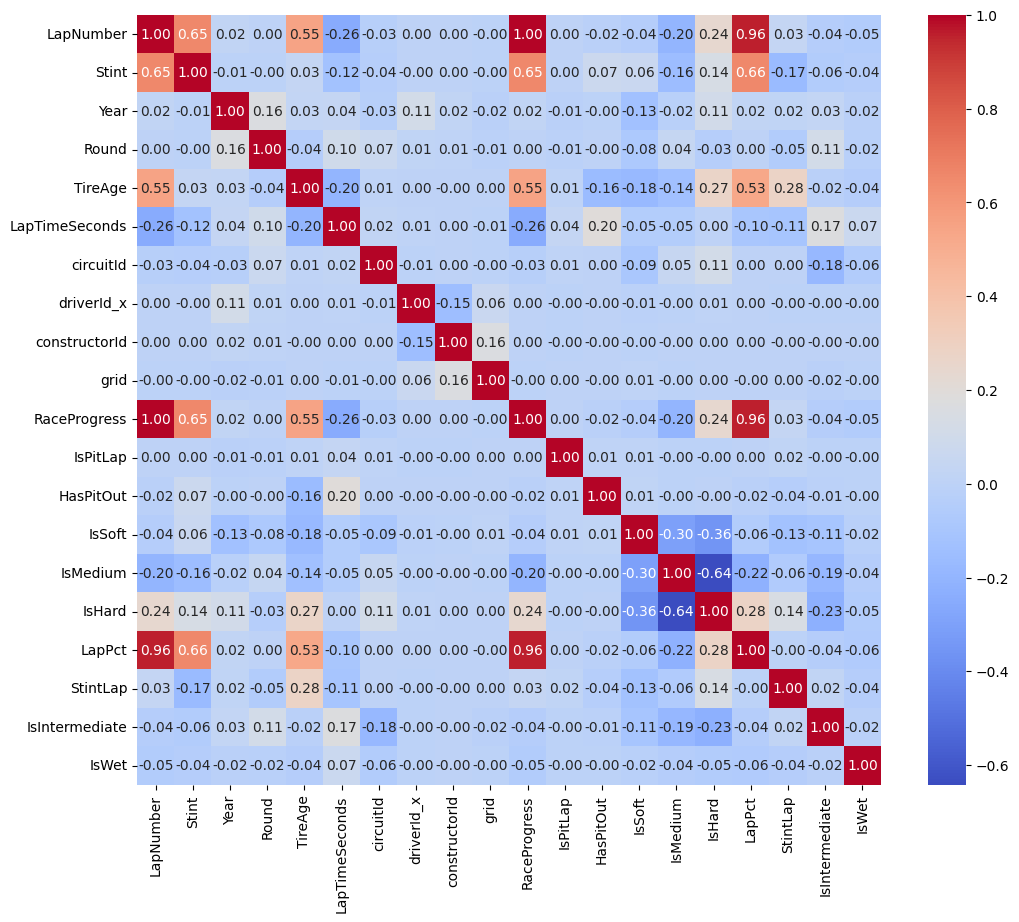

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
figure,ax=plt.subplots(figsize=(12,10))
sns.heatmap(corr,annot=True,fmt=".2f",cmap='coolwarm',ax=ax)
plt.show()

In [11]:
df=df.drop(columns=['LapNumber','RaceProgress','driverId_x','constructorId'])

In [12]:
df.head()

,Driver,Stint,Year,Round,TireAge,LapTimeSeconds,circuitId,grid,Compound_HARD,Compound_INTERMEDIATE,Compound_MEDIUM,Compound_SOFT,Compound_UNKNOWN,Compound_WET,IsPitLap,HasPitOut,LapPct,StintLap
0,GAS,1.0,2020,1,1.0,79.106,70.0,1.0,False,False,True,False,False,False,0,0,0.014925,1
1,GAS,1.0,2020,1,1.0,79.106,70.0,7.0,False,False,True,False,False,False,0,0,0.014925,1
2,GAS,1.0,2020,1,1.0,79.106,70.0,3.0,False,False,True,False,False,False,0,0,0.014925,1
3,GAS,1.0,2020,1,1.0,79.106,70.0,5.0,False,False,True,False,False,False,0,0,0.014925,1
4,GAS,1.0,2020,1,1.0,79.106,70.0,8.0,False,False,True,False,False,False,0,0,0.014925,1


In [13]:
df=df.drop(columns=['Compound_UNKNOWN'])

In [14]:
df.to_csv("dataset/processed_f1_tire_strategy_dataset.csv",index=False)